**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

In [1]:
# Local setup (replaced the Colab Google Drive mount cell)
# Notebooks are opened from their own assignment folder. This cell makes the
# cs231n package importable and verifies the datasets are in place.
import os, sys
NB_DIR = os.getcwd()
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)
os.chdir(NB_DIR)
print("Local setup OK:", NB_DIR)


Local setup OK: E:\ScaleLab\CS231n\project\assignments\assignment1


# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [2]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [3]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


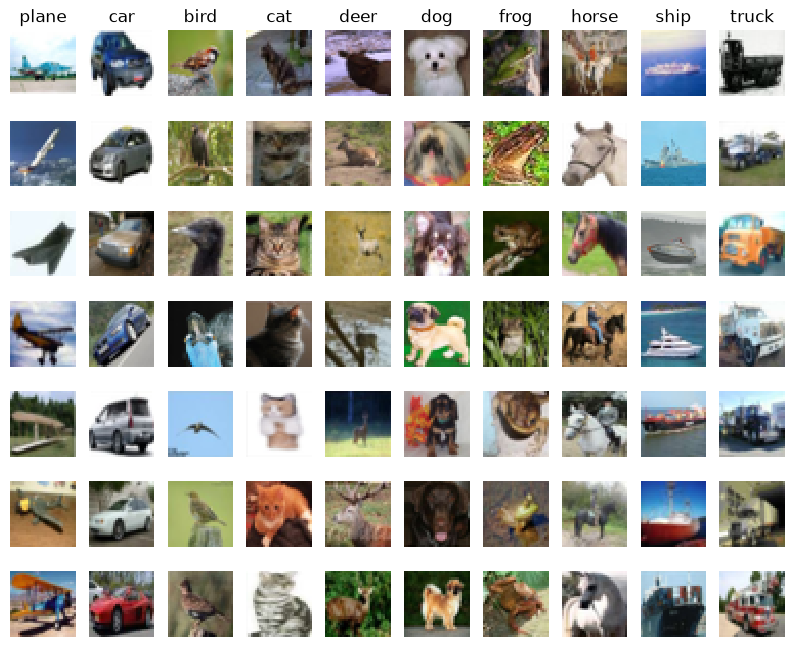

In [4]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [5]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [6]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.68226531 136.03406122 132.521      130.11597959 135.42012245
 131.82012245 131.03538776 136.22916327 132.54777551 131.57118367]


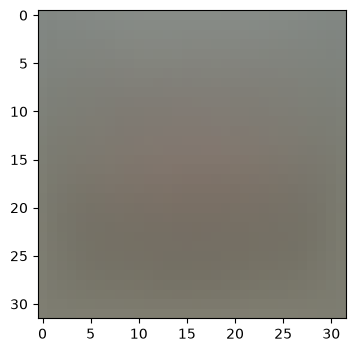

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [7]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [8]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.432951
loss: 2.432951
sanity check: 2.302585


**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$

**Answer / 答案**：When W is initialized to tiny random values (~0.001·randn), all class scores are close to 0, so softmax outputs an almost uniform distribution over 10 classes and each sample's loss is ≈ −log(1/10) = log(10) ≈ 2.30. 权重初始化为很小的随机数时，每个类别的分数都接近 0，softmax 概率近似均匀的 1/10，所以单样本损失≈ −log(1/10)=log(10)≈2.30。



The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [9]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -1.339360 analytic: -1.339360, relative error: 4.994452e-08


numerical: 0.760355 analytic: 0.760355, relative error: 5.521280e-08
numerical: 1.369337 analytic: 1.369337, relative error: 5.732302e-08


numerical: 1.023728 analytic: 1.023728, relative error: 4.139194e-08
numerical: -0.473904 analytic: -0.473904, relative error: 8.098948e-09
numerical: 0.046391 analytic: 0.046391, relative error: 4.494055e-08


numerical: -4.673009 analytic: -4.673009, relative error: 4.905846e-09
numerical: 2.955438 analytic: 2.955438, relative error: 1.555591e-08
numerical: -1.643076 analytic: -1.643076, relative error: 4.181018e-08
numerical: -0.155493 analytic: -0.155493, relative error: 2.706345e-07


numerical: -5.093341 analytic: -5.093341, relative error: 7.447198e-09
numerical: -0.525949 analytic: -0.525949, relative error: 9.633823e-08
numerical: -3.428784 analytic: -3.428784, relative error: 8.011131e-09


numerical: -0.135308 analytic: -0.135308, relative error: 4.444824e-08
numerical: -1.508142 analytic: -1.508142, relative error: 5.249693e-09
numerical: -0.643669 analytic: -0.643669, relative error: 3.535251e-08


numerical: -2.332146 analytic: -2.332146, relative error: 1.027164e-08
numerical: 1.170493 analytic: 1.170493, relative error: 2.333243e-08
numerical: 0.916600 analytic: 0.916600, relative error: 7.445002e-08
numerical: -1.871267 analytic: -1.871267, relative error: 8.576537e-09


**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

Note that SVM loss for a sample $(x_i, y_i)$ is defined as: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ where $j$ iterates over all classes except the correct class $y_i$ and $s_j$ denotes the classifier score for $j^{th}$ class. $\Delta$ is a scalar margin. For more information, refer to 'Multiclass Support Vector Machine loss' on [this](https://cs231n.github.io/linear-classify/) page.

*Hint: the SVM loss function is not strictly speaking differentiable.*


$\color{blue}{\textit Your Answer:}$

**Answer / 答案**：The multiclass hinge loss is not differentiable at the kink where s_j − s_{y_i} + Δ = 0. Numeric gradient perturbs the input by ±h; if the perturbation crosses that kink, the finite difference sees a discontinuous slope change and can disagree with the analytic gradient on that dimension. This is expected, zero-measure behavior, not a concern. 1-D example: with the correct score fixed at 0, L = max(0, s + Δ) is non-differentiable at s = −Δ. A larger margin Δ moves the kink farther away and makes it more likely a random sample lies near it, so gradcheck mismatches become more frequent. 多类 SVM 的 hinge loss 在 s_j−s_y+Δ=0 处不可导；数值梯度 ±h 扰动一旦跨过折点，有限差分就会和解析梯度不一致，个别维度对不上属于正常现象、无需担心。一维例子：L=max(0, s+Δ) 在 s=−Δ 处不可导。Δ 越大，样本落在折点附近的概率越高，梯度检查不一致越频繁。  



In [10]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.432951e+00 computed in 0.034689s
Vectorized loss: 2.432951e+00 computed in 0.000882s
difference: 0.000000


In [11]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.034130s
Vectorized loss and gradient: computed in 0.001004s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

In [12]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 763.849382


iteration 100 / 1500: loss 280.769567


iteration 200 / 1500: loss 104.022160


iteration 300 / 1500: loss 39.368633


iteration 400 / 1500: loss 15.728687


...

iteration 900 / 1500: loss 2.223369


iteration 1000 / 1500: loss 2.121372


iteration 1100 / 1500: loss 2.073915
iteration 1200 / 1500: loss 2.107114


iteration 1300 / 1500: loss 2.128191


iteration 1400 / 1500: loss 2.096083
That took 3.152498s


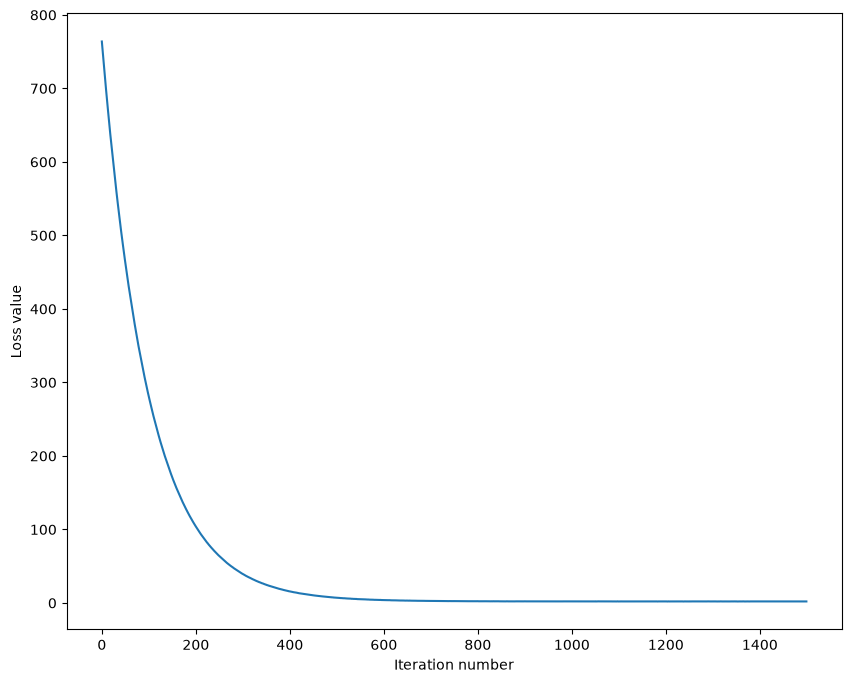

In [13]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [14]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.328327
validation accuracy: 0.311000


In [15]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [16]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). If you are careful you should be able to get a classification
# accuracy of about 0.365 (> 0.36) on the validation set.

# results maps (learning_rate, regularization_strength) ->
# (training_accuracy, validation_accuracy)
results = {}
best_val = -1
best_softmax = None

# 标定过的网格：lr=2e-7, reg=5e3, 6000 轮时验证集约 0.368
learning_rates = [1e-7, 2e-7]
regularization_strengths = [5e3, 1e4]

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg,
                      num_iters=6000, batch_size=200, verbose=False)
        train_accuracy = np.mean(softmax.predict(X_train) == y_train)
        val_accuracy = np.mean(softmax.predict(X_val) == y_val)
        results[(lr, reg)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 5.000000e+03 train accuracy: 0.376510 val accuracy: 0.368000
lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.358959 val accuracy: 0.345000
lr 2.000000e-07 reg 5.000000e+03 train accuracy: 0.374286 val accuracy: 0.361000
lr 2.000000e-07 reg 1.000000e+04 train accuracy: 0.360061 val accuracy: 0.341000
best validation accuracy achieved during cross-validation: 0.368000


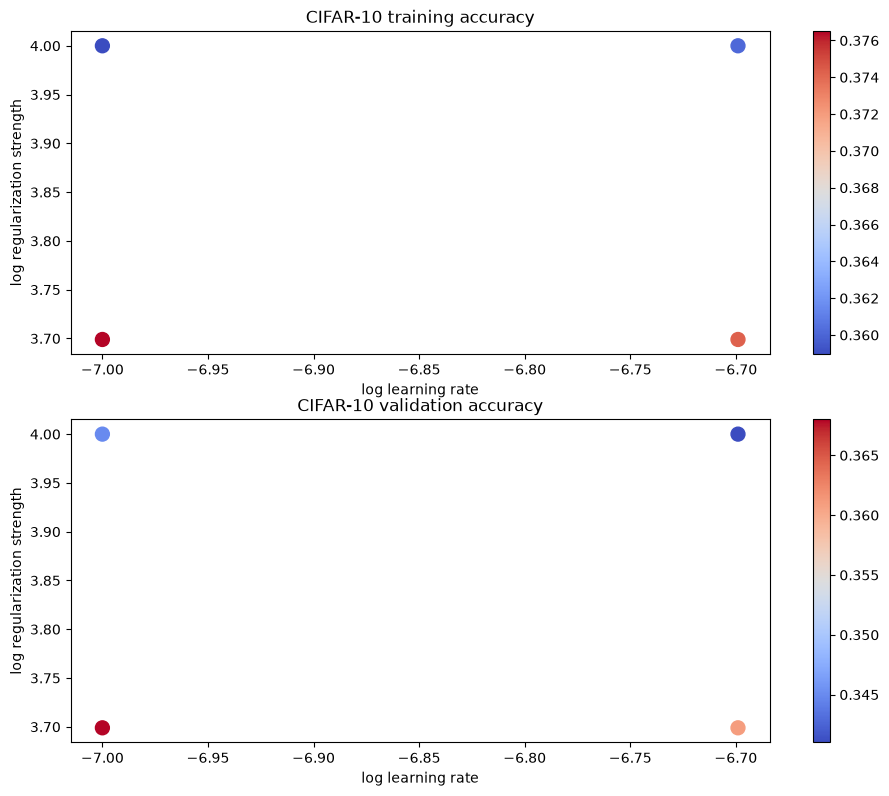

In [17]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [18]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.375000


In [19]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


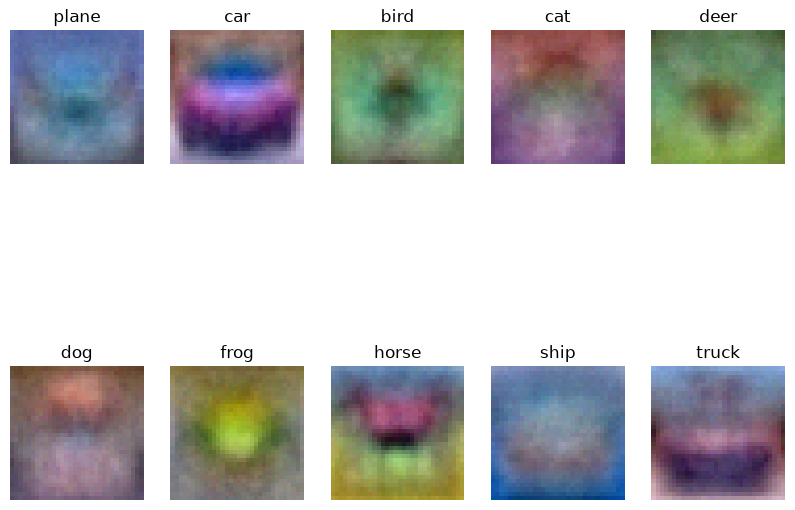

In [20]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$

**Answer / 答案**：Each class weight reshaped back to an image looks like a blurry, noisy "template" of that class. A linear classifier is equivalent to template matching: positive weights mark pixels typical of the class, negative weights mark pixels typical of other classes. Since the model is linear and CIFAR-10 has large intra-class variation, the templates look like average images with ghosting rather than sharp pictures. 每个类别的权重向量还原成图像后，像一张模糊带噪的"模板"。线性分类器等价于模板匹配：正权重是这类图片常见的位置，负权重是其他类常见的位置。由于模型是线性的且类内差异大，模板看起来像均值图而非清晰图像。  


**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:}$

**Answer / 答案**：True（正确）

$\color{blue}{\textit Your Explanation:}$

Softmax loss receives a nonzero contribution from every training point, no matter how confidently it is classified, so adding any point generally changes the total loss. The multiclass SVM loss, in contrast, is exactly zero for points whose correct-class score already exceeds all others by at least the margin Δ; adding such an "easy" point leaves the SVM loss unchanged while still changing the softmax loss. softmax 对每个样本都有非零的损失贡献；而 SVM 损失对"正确类别已超出其他类 Δ 以上"的样本恰好为 0，所以新增这样一个样本不会改变 SVM 损失，却会改变 softmax 损失。

